In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

In [2]:
valid = pd.read_csv('../../../../results/translation_efficiency/training_data/1_absolute/valid.tsv', sep='\t')
scores = pd.read_csv('../../../../results/translation_efficiency/training_data/1_absolute/models/pcv2-l48-d1536/valid_predictions.tsv', sep='\t')
valid['scores'] = scores['predicted_value']
valid.head()

,gene,chr,strand,TPM,seq,label,scores
0,AT1G01030,1,-,1.088918,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.319921,0.449870
1,AT1G01070,1,-,5.516785,ATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATTAACTTTTCA...,0.814033,0.500158
2,AT1G01100,1,-,323.478734,TAAATATGTCAAATGAAGAATTATGTTACTAGTGCGAAAAGGACAT...,2.511186,1.600904
3,AT1G01120,1,-,95.581248,ATTAACAAGTTATGTTGTTTATCAAAAACTTCAAAAAAAAAAAAAA...,1.984893,0.833954
4,AT1G01200,1,-,2.641557,TGGAGCATAAGAGCTTTTTTAGGTGGTCTCCAGACAAATCGTGGGT...,0.561287,0.932936


In [3]:
ism = pd.read_csv('../../../../results/translation_efficiency/training_data/1_absolute/valid_ism.tsv', sep='\t')
ism_scores = pd.read_csv('../../../../results/translation_efficiency/training_data/1_absolute/models/pcv2-l48-d1536/valid_ism_scores.tsv', sep='\t')
ism['scores'] = ism_scores['predicted_value']
ism.head()

,gene,original_index,pos,original_base,mutated_base,seq,scores
0,AT1G01030,0,-100,T,A,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.447782
1,AT1G01030,0,-100,T,C,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.453850
2,AT1G01030,0,-100,T,G,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.454653
3,AT1G01030,0,-99,T,A,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.451058
4,AT1G01030,0,-99,T,C,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.462708


In [4]:
def calculate_position_importance():
    """Calculate importance score for each position based on ISM results"""
    print("Calculating position importance scores...")
    
    # Use all available sequences for regression analysis
    all_indices = valid.index
    print(f"Total sequences for analysis: {len(all_indices)}")
    
    position_importance = {}
    nucleotide_contributions = {}
    
    processed = 0
    for idx in all_indices:
        if idx not in ism['original_index'].values:
            continue
            
        group = ism[ism['original_index'] == idx]
        original_score = valid.loc[idx, 'scores']
        
        for _, row in group.iterrows():
            pos = row['pos']  # Position relative to ATG (-100 to -1)
            mut_base = row['mutated_base']
            
            # For regression, use direct score difference
            delta_score = row['scores'] - original_score  # Signed score difference
            abs_delta_score = abs(delta_score)  # Absolute score difference
            
            # Apply transformation to amplify differences
            # Option 1: Square the differences to amplify larger effects
            # abs_delta_score = abs_delta_score ** 2
            # delta_score = np.sign(delta_score) * (abs(delta_score) ** 2)
            
            # Option 2: Log transformation (add small constant to avoid log(0))
            # abs_delta_score = np.log(abs_delta_score + 1e-8)
            # delta_score = np.sign(delta_score) * np.log(abs(delta_score) + 1e-8)
            
            # Option 3: Multiply by a scaling factor
            scaling_factor = 100  # Amplify by 100x
            abs_delta_score = abs_delta_score * scaling_factor
            delta_score = delta_score * scaling_factor
            
            # Overall position importance (absolute score difference)
            if pos not in position_importance:
                position_importance[pos] = []
            position_importance[pos].append(abs_delta_score)
            
            # Nucleotide-specific contribution (signed score difference)
            if pos not in nucleotide_contributions:
                nucleotide_contributions[pos] = {'A': [], 'C': [], 'G': [], 'T': []}
            nucleotide_contributions[pos][mut_base].append(delta_score)
        
        processed += 1
        if processed % 500 == 0:
            print(f"Processed {processed} sequences...")
    
    print(f"Finished processing {processed} sequences")
    
    # Calculate statistics
    pos_stats = {}
    for pos, scores in position_importance.items():
        if scores:  # Only if we have data for this position
            pos_stats[pos] = {
                'mean': np.mean(scores),
                'std': np.std(scores),
                'median': np.median(scores),
                'count': len(scores)
            }
    
    nucleotide_stats = {}
    for pos in nucleotide_contributions:
        nucleotide_stats[pos] = {}
        for base in ['A', 'C', 'G', 'T']:
            if nucleotide_contributions[pos][base]:
                nucleotide_stats[pos][base] = np.mean(nucleotide_contributions[pos][base])
            else:
                nucleotide_stats[pos][base] = 0.0
    
    # Apply additional normalization to nucleotide stats for better visualization
    print("Applying z-score normalization to nucleotide contributions...")
    
    # Collect all nucleotide contribution values for z-score normalization
    all_values = []
    for pos in nucleotide_stats:
        for base in ['A', 'C', 'G', 'T']:
            all_values.append(nucleotide_stats[pos][base])
    
    if all_values:
        mean_val = np.mean(all_values)
        std_val = np.std(all_values)
        
        # Apply z-score normalization
        for pos in nucleotide_stats:
            for base in ['A', 'C', 'G', 'T']:
                if std_val > 0:
                    nucleotide_stats[pos][base] = (nucleotide_stats[pos][base] - mean_val) / std_val
                else:
                    nucleotide_stats[pos][base] = 0.0
    
    return pos_stats, nucleotide_stats

In [5]:
# Calculate importance with caching
import pickle
import os

cache_file = 'ism_importance_cache.pkl'

if os.path.exists(cache_file):
    print("Loading cached importance scores...")
    try:
        with open(cache_file, 'rb') as f:
            results = pickle.load(f)
        # Check if it's the new format (tuple) or old format (dictionary)
        if isinstance(results, tuple) and len(results) == 2:
            print("Cached data loaded!")
        else:
            print("Old cache format detected, recalculating...")
            raise ValueError("Old cache format")
    except:
        print("Cache file incompatible, recalculating...")
        results = calculate_position_importance()
        print("Importance calculation completed!")
        
        print("Saving results to cache...")
        with open(cache_file, 'wb') as f:
            pickle.dump(results, f)
        print("Cache saved!")
else:
    print("Starting importance calculation...")
    results = calculate_position_importance()
    print("Importance calculation completed!")
    
    print("Saving results to cache...")
    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)
    print("Cache saved!")

# Extract results
pos_importance, nucleotide_stats = results

# Convert to DataFrame for plotting
print("Converting results to DataFrame for plotting...")

# Position importance DataFrame
pos_df = pd.DataFrame(pos_importance).T
pos_df.index.name = 'position'
pos_df = pos_df.reset_index().sort_values('position')

# Nucleotide contributions DataFrame
nucleotide_df = pd.DataFrame(nucleotide_stats).T
nucleotide_df.index.name = 'position'
nucleotide_df = nucleotide_df.reset_index().sort_values('position')

Loading cached importance scores...
Old cache format detected, recalculating...
Cache file incompatible, recalculating...
Calculating position importance scores...
Total sequences for analysis: 5492
Processed 500 sequences...
Processed 1000 sequences...
Processed 1500 sequences...
Processed 2000 sequences...
Processed 2500 sequences...
Processed 3000 sequences...
Processed 3500 sequences...
Processed 4000 sequences...
Processed 4500 sequences...
Processed 5000 sequences...
Finished processing 5492 sequences
Applying z-score normalization to nucleotide contributions...
Importance calculation completed!
Saving results to cache...
Cache saved!
Converting results to DataFrame for plotting...


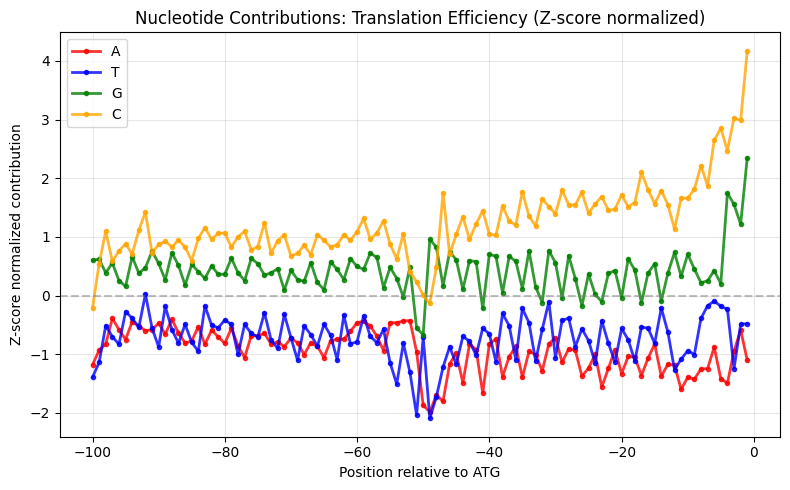

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
colors = {'A': 'red', 'T': 'blue', 'G': 'green', 'C': 'orange'}
# Plot 2: Nucleotide contributions (full range)
for base in ['A', 'T', 'G', 'C']:
   axes.plot(nucleotide_df['position'], nucleotide_df[base], 'o-', 
               linewidth=2, markersize=3, color=colors[base], label=f'{base}', alpha=0.8)
axes.set_xlabel('Position relative to ATG')
axes.set_ylabel('Z-score normalized contribution')
axes.set_title('Nucleotide Contributions: Translation Efficiency (Z-score normalized)')
axes.grid(True, alpha=0.3)
axes.legend()
axes.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nucleotide_contributions.pdf', format='pdf', bbox_inches='tight')
plt.show()